In [4]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [5]:
dataset = pd.read_csv(r'part-00000-bc8041e1-56a7-4223-b839-8474dfbae85d-c000.csv')
dataset = dataset.drop(columns=[
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "shipping_delay_hours",
    "delivery_time_days",
    "review_score"
])

dataset.to_csv("novo_arquivo.csv", index=False)

In [6]:
dataset = pd.read_csv(r'novo_arquivo.csv')
X = dataset.drop(columns=["delivered_on_time"])
y = dataset["delivered_on_time"]

In [7]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state = 42)

In [8]:
from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... note:: The search for a split does not stop until at least one valid partition of the node samples is found, even if it requires to effectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",42
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current

In [9]:
novo = X_test.iloc[[0]]
print(classifier.predict(novo))

[1]


In [10]:
y_pred = classifier.predict(X_test)

# Matriz de Confusão

In [11]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score
cm = confusion_matrix(y_test, y_pred)
print(cm)
print(accuracy_score(y_test, y_pred))
print(precision_score(y_test, y_pred))
print(recall_score(y_test, y_pred))


[[ 129  264]
 [ 337 6034]]
0.9111472501478415
0.9580819307716736
0.9471040652958719


Propriedades do Classificador

In [12]:
print(classifier.predict_proba(novo))
print(classifier.classes_)
print(classifier.max_features_)
print(classifier.feature_importances_)
print(classifier.n_features_in_)

[[0. 1.]]
[0 1]
65
[0.         0.08503613 0.15109976 0.0317054  0.03222978 0.00180606
 0.05994907 0.05372637 0.04673652 0.05957128 0.05631042 0.00268658
 0.02447503 0.01679658 0.00391073 0.00909229 0.06007152 0.01866588
 0.00308642 0.0094896  0.02037067 0.01819706 0.00823587 0.00608212
 0.04688074 0.01886734 0.00128053 0.01344758 0.04421947 0.0294594
 0.00032363 0.00031176 0.02226339 0.00133962 0.00052859 0.00170444
 0.00178527 0.00342483 0.00171942 0.00063616 0.00338164 0.00096435
 0.00029148 0.00049977 0.00105578 0.00065524 0.0005831  0.
 0.         0.         0.00164406 0.00634368 0.00339108 0.00081678
 0.00161739 0.00049315 0.00425338 0.00235172 0.00068126 0.
 0.00118302 0.0009028  0.0009355  0.         0.0004315 ]
65


Visualizar dados de treinamento

 



c:\Users\gques\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


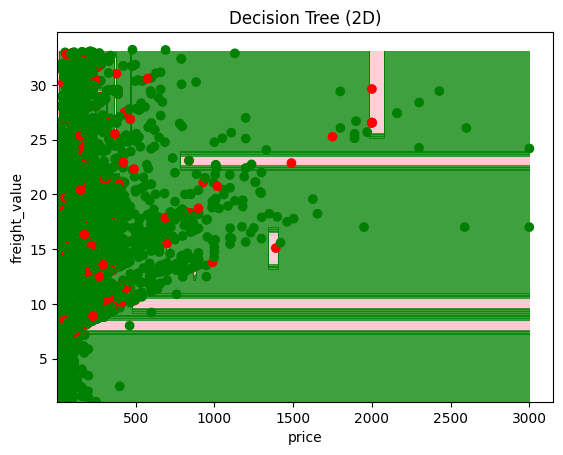

In [13]:
X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_train.values
y_set = y_train.values

from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.scatter(X_set[:, 0], X_set[:, 1], c=y_set, cmap=ListedColormap(('red', 'green')))
plt.xlabel("price")
plt.ylabel("freight_value")
plt.title("Decision Tree (2D)")
plt.show()

Visualizar dados de teste

c:\Users\gques\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\gques\AppData\Local\Temp\ipykernel_12928\1824099838.py:34: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  plt.scatter(


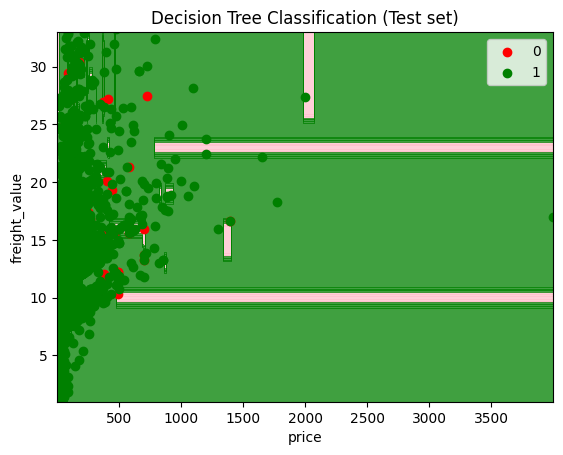

In [14]:
from matplotlib.colors import ListedColormap
import matplotlib.pyplot as plt
import numpy as np

X_2d = dataset[["price", "freight_value"]]
y = dataset["delivered_on_time"]

from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X_2d, y, test_size=0.2, random_state=42)

from sklearn.tree import DecisionTreeClassifier
classifier = DecisionTreeClassifier(random_state=42)
classifier.fit(X_train, y_train)

X_set = X_test.values
y_set = y_test.values

X1, X2 = np.meshgrid(
    np.arange(start=X_set[:, 0].min(), stop=X_set[:, 0].max(), step=1),
    np.arange(start=X_set[:, 1].min(), stop=X_set[:, 1].max(), step=1)
)

plt.contourf(
    X1, X2,
    classifier.predict(np.array([X1.ravel(), X2.ravel()]).T).reshape(X1.shape),
    alpha=0.75,
    cmap=ListedColormap(('pink', 'green'))
)

plt.xlim(X1.min(), X1.max())
plt.ylim(X2.min(), X2.max())

for i, j in enumerate(np.unique(y_set)):
    plt.scatter(
        X_set[y_set == j, 0],
        X_set[y_set == j, 1],
        c=ListedColormap(('red', 'green'))(i),
        label=j
    )

plt.title('Decision Tree Classification (Test set)')
plt.xlabel('price')
plt.ylabel('freight_value')
plt.legend()
plt.show()

## Modelo Melhorado

Versao robusta com:
- split estratificado
- tratamento de nulos e variaveis categoricas via pipeline
- busca de hiperparametros com GridSearchCV
- metricas completas no teste e em validacao cruzada

MELHOR CONFIGURACAO ENCONTRADA (GRID SEARCH)
Hiperparametros:
{'model__ccp_alpha': 0.0, 'model__criterion': 'entropy', 'model__max_depth': None, 'model__min_samples_leaf': 1, 'model__min_samples_split': 2}
Melhor F1 (CV): 0.9152

DESEMPENHO NO CONJUNTO DE TESTE
Accuracy             : 0.9140
Precision (weighted) : 0.9208
Recall (weighted)    : 0.9140
F1 (weighted)        : 0.9172

Relatorio por classe:
              precision    recall  f1-score   support

           0       0.32      0.38      0.34       408
           1       0.96      0.95      0.95      6356

    accuracy                           0.91      6764
   macro avg       0.64      0.66      0.65      6764
weighted avg       0.92      0.91      0.92      6764



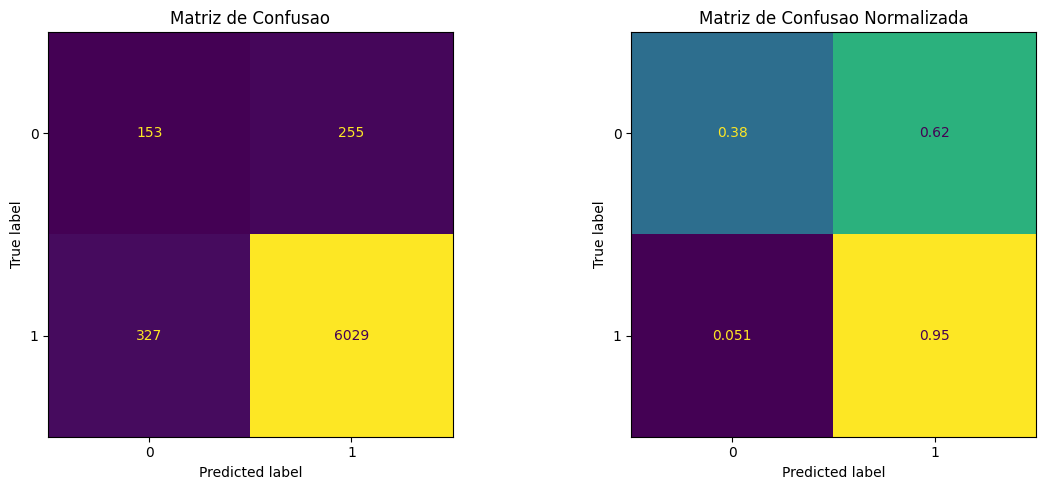

METRICAS DE PROBABILIDADE (BINARIO)
ROC-AUC: 0.6618
PR-AUC : 0.9584

ESTABILIDADE EM VALIDACAO CRUZADA (TREINO)
accuracy             -> media: 0.9145 | desvio: 0.0033
precision_weighted   -> media: 0.9161 | desvio: 0.0018
recall_weighted      -> media: 0.9145 | desvio: 0.0033
f1_weighted          -> media: 0.9152 | desvio: 0.0024

TOP 15 FEATURES MAIS IMPORTANTES
                                   feature  importance
                  num__handling_time_hours    0.189931
                                num__month    0.085826
                  num__approval_time_hours    0.077059
                          num__distance_km    0.069418
       num__seller_max_wind_gust_period_ms    0.055872
                           num__volume_cm3    0.055428
                        num__freight_value    0.054974
     num__customer_max_wind_gust_period_ms    0.047285
                                num__price    0.044390
                     num__product_weight_g    0.041538
                        num__

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    average_precision_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, cross_validate, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier

# 1) Preparacao dos dados
if "delivered_on_time" not in dataset.columns:
    raise ValueError("A coluna alvo 'delivered_on_time' nao foi encontrada no dataset.")

X = dataset.drop(columns=["delivered_on_time"])
y = dataset["delivered_on_time"]

if y.nunique() < 2:
    raise ValueError("A coluna alvo precisa ter pelo menos duas classes para classificacao.")

# 2) Split estratificado
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

# 3) Pipeline de preprocessamento + modelo
numeric_features = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=[np.number]).columns.tolist()

numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

pipeline = Pipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

param_grid = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 5, 8, 12, None],
    "model__min_samples_split": [2, 10, 30],
    "model__min_samples_leaf": [1, 5, 10],
    "model__ccp_alpha": [0.0, 0.001, 0.01],
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_weighted",
    n_jobs=-1,
    refit=True,
)

grid.fit(X_train, y_train)
best_model = grid.best_estimator_

print("=" * 70)
print("MELHOR CONFIGURACAO ENCONTRADA (GRID SEARCH)")
print("=" * 70)
print("Hiperparametros:")
print(grid.best_params_)
print(f"Melhor F1 (CV): {grid.best_score_:.4f}")

# 4) Avaliacao no conjunto de teste
y_pred = best_model.predict(X_test)

print("\n" + "=" * 70)
print("DESEMPENHO NO CONJUNTO DE TESTE")
print("=" * 70)
print(f"Accuracy             : {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision (weighted) : {precision_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"Recall (weighted)    : {recall_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")
print(f"F1 (weighted)        : {f1_score(y_test, y_pred, average='weighted', zero_division=0):.4f}")

print("\nRelatorio por classe:")
print(classification_report(y_test, y_pred, zero_division=0))

cm = confusion_matrix(y_test, y_pred)
cm_norm = confusion_matrix(y_test, y_pred, normalize="true")

fig, ax = plt.subplots(1, 2, figsize=(12, 5))
ConfusionMatrixDisplay(confusion_matrix=cm).plot(ax=ax[0], colorbar=False)
ax[0].set_title("Matriz de Confusao")
ConfusionMatrixDisplay(confusion_matrix=cm_norm).plot(ax=ax[1], colorbar=False)
ax[1].set_title("Matriz de Confusao Normalizada")
plt.tight_layout()
plt.show()

# 5) ROC-AUC e PR-AUC para classificacao binaria
if y.nunique() == 2 and hasattr(best_model, "predict_proba"):
    y_proba = best_model.predict_proba(X_test)[:, 1]
    print("=" * 70)
    print("METRICAS DE PROBABILIDADE (BINARIO)")
    print("=" * 70)
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    print(f"PR-AUC : {average_precision_score(y_test, y_proba):.4f}")

# 6) Estabilidade das metricas via validacao cruzada
cv_scores = cross_validate(
    best_model,
    X_train,
    y_train,
    cv=cv,
    scoring=["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"],
    n_jobs=-1,
)

print("\n" + "=" * 70)
print("ESTABILIDADE EM VALIDACAO CRUZADA (TREINO)")
print("=" * 70)
for metric in ["accuracy", "precision_weighted", "recall_weighted", "f1_weighted"]:
    values = cv_scores[f"test_{metric}"]
    print(f"{metric:<20} -> media: {values.mean():.4f} | desvio: {values.std():.4f}")

# 7) Top importancias das features (apos preprocessamento)
feature_names = best_model.named_steps["preprocess"].get_feature_names_out()
importances = best_model.named_steps["model"].feature_importances_

importance_df = pd.DataFrame(
    {
        "feature": feature_names,
        "importance": importances,
    }
).sort_values("importance", ascending=False)

print("\n" + "=" * 70)
print("TOP 15 FEATURES MAIS IMPORTANTES")
print("=" * 70)
print(importance_df.head(15).to_string(index=False))

In [16]:
from sklearn.metrics import accuracy_score, f1_score

# Diagnostico rapido de overfitting
train_pred = best_model.predict(X_train)
test_pred = best_model.predict(X_test)

train_acc = accuracy_score(y_train, train_pred)
test_acc = accuracy_score(y_test, test_pred)
train_f1 = f1_score(y_train, train_pred, average="weighted", zero_division=0)
test_f1 = f1_score(y_test, test_pred, average="weighted", zero_division=0)

print("=" * 70)
print("DIAGNOSTICO DE OVERFITTING")
print("=" * 70)
print(f"Accuracy treino: {train_acc:.4f}")
print(f"Accuracy teste : {test_acc:.4f}")
print(f"Gap accuracy   : {(train_acc - test_acc):.4f}")
print()
print(f"F1 treino      : {train_f1:.4f}")
print(f"F1 teste       : {test_f1:.4f}")
print(f"Gap F1         : {(train_f1 - test_f1):.4f}")

DIAGNOSTICO DE OVERFITTING
Accuracy treino: 1.0000
Accuracy teste : 0.9140
Gap accuracy   : 0.0860

F1 treino      : 1.0000
F1 teste       : 0.9172
Gap F1         : 0.0828


## Rodada 2: Reducao de Overfitting e Foco na Classe 0

Nesta etapa:
- restringimos a complexidade da arvore (poda e limites)
- otimizamos por `f1_macro` (mais justo para classes desbalanceadas)
- ajustamos o limiar de decisao para melhorar a classe 0

In [17]:
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, f1_score, recall_score
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.tree import DecisionTreeClassifier
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

# Reconstroi os dados para garantir independencia desta rodada
X_all = dataset.drop(columns=["delivered_on_time"])
y_all = dataset["delivered_on_time"]

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_all,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all,
)

# Separa validacao interna para ajuste do limiar sem usar o teste final
X_train_inner, X_val, y_train_inner, y_val = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

num_cols = X_train_inner.select_dtypes(include=[np.number]).columns.tolist()
cat_cols = X_train_inner.select_dtypes(exclude=[np.number]).columns.tolist()

preprocessor_v2 = ColumnTransformer(
    transformers=[
        ("num", Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))]), num_cols),
        (
            "cat",
            Pipeline(
                steps=[
                    ("imputer", SimpleImputer(strategy="most_frequent")),
                    ("onehot", OneHotEncoder(handle_unknown="ignore")),
                ]
            ),
            cat_cols,
        ),
    ]
)

pipeline_v2 = Pipeline(
    steps=[
        ("preprocess", preprocessor_v2),
        (
            "model",
            DecisionTreeClassifier(
                random_state=42,
                class_weight="balanced",
            ),
        ),
    ]
)

# Grade mais conservadora para reduzir overfitting
param_grid_v2 = {
    "model__criterion": ["gini", "entropy"],
    "model__max_depth": [3, 4, 5, 6, 8],
    "model__min_samples_split": [20, 50, 100],
    "model__min_samples_leaf": [10, 20, 40],
    "model__ccp_alpha": [0.0, 0.001, 0.005, 0.01, 0.02],
}

cv_v2 = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_v2 = GridSearchCV(
    estimator=pipeline_v2,
    param_grid=param_grid_v2,
    cv=cv_v2,
    scoring="f1_macro",
    n_jobs=-1,
    refit=True,
)

grid_v2.fit(X_train_inner, y_train_inner)
best_model_v2 = grid_v2.best_estimator_

print("=" * 70)
print("RODADA 2 - MELHOR MODELO (FOCO EM F1 MACRO)")
print("=" * 70)
print("Hiperparametros:")
print(grid_v2.best_params_)
print(f"Melhor F1 macro (CV): {grid_v2.best_score_:.4f}")

# Avaliacao com limiar padrao (0.5)
y_train_pred_default = best_model_v2.predict(X_train_full)
y_test_pred_default = best_model_v2.predict(X_test_full)

train_f1_default = f1_score(y_train_full, y_train_pred_default, average="macro", zero_division=0)
test_f1_default = f1_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)

print("\n" + "=" * 70)
print("LIMIAR PADRAO (0.5)")
print("=" * 70)
print(f"F1 macro treino: {train_f1_default:.4f}")
print(f"F1 macro teste : {test_f1_default:.4f}")
print(f"Gap F1 macro   : {(train_f1_default - test_f1_default):.4f}")
print(f"Recall classe 0 (teste): {recall_score(y_test_full, y_test_pred_default, pos_label=0):.4f}")
print("\nRelatorio (teste, limiar padrao):")
print(classification_report(y_test_full, y_test_pred_default, zero_division=0))

# Ajuste de limiar usando validacao interna (sem tocar no teste)
classes_order = best_model_v2.classes_
if 1 in classes_order:
    idx_pos = int(np.where(classes_order == 1)[0][0])
else:
    idx_pos = 1

val_proba_pos = best_model_v2.predict_proba(X_val)[:, idx_pos]

best_threshold = 0.5
best_score = -1.0
for t in np.arange(0.20, 0.81, 0.02):
    pred_val = (val_proba_pos >= t).astype(int)
    score = f1_score(y_val, pred_val, average="macro", zero_division=0)
    if score > best_score:
        best_score = score
        best_threshold = float(t)

# Aplica limiar ajustado no teste final
test_proba_pos = best_model_v2.predict_proba(X_test_full)[:, idx_pos]
y_test_pred_tuned = (test_proba_pos >= best_threshold).astype(int)

print("\n" + "=" * 70)
print("LIMIAR AJUSTADO")
print("=" * 70)
print(f"Melhor limiar (validacao): {best_threshold:.2f}")
print(f"F1 macro no teste        : {f1_score(y_test_full, y_test_pred_tuned, average='macro', zero_division=0):.4f}")
print(f"Recall classe 0 (teste)  : {recall_score(y_test_full, y_test_pred_tuned, pos_label=0):.4f}")
print("\nRelatorio (teste, limiar ajustado):")
print(classification_report(y_test_full, y_test_pred_tuned, zero_division=0))

RODADA 2 - MELHOR MODELO (FOCO EM F1 MACRO)
Hiperparametros:
{'model__ccp_alpha': 0.01, 'model__criterion': 'gini', 'model__max_depth': 3, 'model__min_samples_leaf': 10, 'model__min_samples_split': 20}
Melhor F1 macro (CV): 0.5924

LIMIAR PADRAO (0.5)
F1 macro treino: 0.5960
F1 macro teste : 0.6084
Gap F1 macro   : -0.0124
Recall classe 0 (teste): 0.4020

Relatorio (teste, limiar padrao):
              precision    recall  f1-score   support

           0       0.22      0.40      0.28       408
           1       0.96      0.91      0.93      6356

    accuracy                           0.88      6764
   macro avg       0.59      0.66      0.61      6764
weighted avg       0.91      0.88      0.89      6764


LIMIAR AJUSTADO
Melhor limiar (validacao): 0.22
F1 macro no teste        : 0.6084
Recall classe 0 (teste)  : 0.4020

Relatorio (teste, limiar ajustado):
              precision    recall  f1-score   support

           0       0.22      0.40      0.28       408
           1      

In [18]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

print("=" * 90)
print("METRICAS SEPARADAS - RELATORIO")
print("=" * 90)
print("LEGENDA:")
print("- Accuracy: proporcao total de acertos")
print("- Precision: entre o que o modelo previu como uma classe, quanto estava correto")
print("- Recall: entre o que realmente era da classe, quanto o modelo encontrou")
print("- F1-score: equilibrio entre precision e recall")
print("- Macro: media simples entre as classes (mesmo peso)")
print("- Weighted: media ponderada pela quantidade de exemplos por classe")

# --- Limiar padrao (0.5) ---
acc_default = accuracy_score(y_test_full, y_test_pred_default)
prec_default_macro = precision_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)
rec_default_macro = recall_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)
f1_default_macro = f1_score(y_test_full, y_test_pred_default, average="macro", zero_division=0)

prec_default_weighted = precision_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)
rec_default_weighted = recall_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)
f1_default_weighted = f1_score(y_test_full, y_test_pred_default, average="weighted", zero_division=0)

prec_default_c0 = precision_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)
rec_default_c0 = recall_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)
f1_default_c0 = f1_score(y_test_full, y_test_pred_default, pos_label=0, zero_division=0)

prec_default_c1 = precision_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)
rec_default_c1 = recall_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)
f1_default_c1 = f1_score(y_test_full, y_test_pred_default, pos_label=1, zero_division=0)

print("\n" + "=" * 90)
print("[LIMIAR PADRAO 0.5]")
print("=" * 90)
print(f"Accuracy (acerto geral)                               : {acc_default:.4f}")
print(f"Precision macro (peso igual entre classes)            : {prec_default_macro:.4f}")
print(f"Recall macro (peso igual entre classes)               : {rec_default_macro:.4f}")
print(f"F1 macro (equilibrio geral entre classes)             : {f1_default_macro:.4f}")
print(f"Precision weighted (ponderado pelo tamanho da classe) : {prec_default_weighted:.4f}")
print(f"Recall weighted (ponderado pelo tamanho da classe)    : {rec_default_weighted:.4f}")
print(f"F1 weighted (ponderado pelo tamanho da classe)        : {f1_default_weighted:.4f}")
print(f"Precision classe 0                                    : {prec_default_c0:.4f}")
print(f"Recall classe 0                                       : {rec_default_c0:.4f}")
print(f"F1 classe 0                                           : {f1_default_c0:.4f}")
print(f"Precision classe 1                                    : {prec_default_c1:.4f}")
print(f"Recall classe 1                                       : {rec_default_c1:.4f}")
print(f"F1 classe 1                                           : {f1_default_c1:.4f}")

# --- Limiar ajustado ---
acc_tuned = accuracy_score(y_test_full, y_test_pred_tuned)
prec_tuned_macro = precision_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)
rec_tuned_macro = recall_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)
f1_tuned_macro = f1_score(y_test_full, y_test_pred_tuned, average="macro", zero_division=0)

prec_tuned_weighted = precision_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)
rec_tuned_weighted = recall_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)
f1_tuned_weighted = f1_score(y_test_full, y_test_pred_tuned, average="weighted", zero_division=0)

prec_tuned_c0 = precision_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)
rec_tuned_c0 = recall_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)
f1_tuned_c0 = f1_score(y_test_full, y_test_pred_tuned, pos_label=0, zero_division=0)

prec_tuned_c1 = precision_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)
rec_tuned_c1 = recall_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)
f1_tuned_c1 = f1_score(y_test_full, y_test_pred_tuned, pos_label=1, zero_division=0)

print("\n" + "=" * 90)
print("[LIMIAR AJUSTADO]")
print("=" * 90)
print(f"Accuracy (acerto geral)                               : {acc_tuned:.4f}")
print(f"Precision macro (peso igual entre classes)            : {prec_tuned_macro:.4f}")
print(f"Recall macro (peso igual entre classes)               : {rec_tuned_macro:.4f}")
print(f"F1 macro (equilibrio geral entre classes)             : {f1_tuned_macro:.4f}")
print(f"Precision weighted (ponderado pelo tamanho da classe) : {prec_tuned_weighted:.4f}")
print(f"Recall weighted (ponderado pelo tamanho da classe)    : {rec_tuned_weighted:.4f}")
print(f"F1 weighted (ponderado pelo tamanho da classe)        : {f1_tuned_weighted:.4f}")
print(f"Precision classe 0                                    : {prec_tuned_c0:.4f}")
print(f"Recall classe 0                                       : {rec_tuned_c0:.4f}")
print(f"F1 classe 0                                           : {f1_tuned_c0:.4f}")
print(f"Precision classe 1                                    : {prec_tuned_c1:.4f}")
print(f"Recall classe 1                                       : {rec_tuned_c1:.4f}")
print(f"F1 classe 1                                           : {f1_tuned_c1:.4f}")

METRICAS SEPARADAS - RELATORIO
LEGENDA:
- Accuracy: proporcao total de acertos
- Precision: entre o que o modelo previu como uma classe, quanto estava correto
- Recall: entre o que realmente era da classe, quanto o modelo encontrou
- F1-score: equilibrio entre precision e recall
- Macro: media simples entre as classes (mesmo peso)
- Weighted: media ponderada pela quantidade de exemplos por classe

[LIMIAR PADRAO 0.5]
Accuracy (acerto geral)                               : 0.8776
Precision macro (peso igual entre classes)            : 0.5893
Recall macro (peso igual entre classes)               : 0.6550
F1 macro (equilibrio geral entre classes)             : 0.6084
Precision weighted (ponderado pelo tamanho da classe) : 0.9148
Recall weighted (ponderado pelo tamanho da classe)    : 0.8776
F1 weighted (ponderado pelo tamanho da classe)        : 0.8939
Precision classe 0                                    : 0.2193
Recall classe 0                                       : 0.4020
F1 classe 0 

In [19]:
import pandas as pd

# Tabela consolidada de metricas para relatorio
metricas_relatorio = pd.DataFrame(
    [
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Accuracy", "Valor": acc_default},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision macro", "Valor": prec_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall macro", "Valor": rec_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 macro", "Valor": f1_default_macro},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision weighted", "Valor": prec_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall weighted", "Valor": rec_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 weighted", "Valor": f1_default_weighted},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision classe 0", "Valor": prec_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall classe 0", "Valor": rec_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 classe 0", "Valor": f1_default_c0},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Precision classe 1", "Valor": prec_default_c1},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "Recall classe 1", "Valor": rec_default_c1},
        {"Cenario": "Limiar padrao (0.5)", "Metrica": "F1 classe 1", "Valor": f1_default_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Accuracy", "Valor": acc_tuned},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision macro", "Valor": prec_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall macro", "Valor": rec_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 macro", "Valor": f1_tuned_macro},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision weighted", "Valor": prec_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall weighted", "Valor": rec_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 weighted", "Valor": f1_tuned_weighted},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision classe 0", "Valor": prec_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall classe 0", "Valor": rec_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 classe 0", "Valor": f1_tuned_c0},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Precision classe 1", "Valor": prec_tuned_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "Recall classe 1", "Valor": rec_tuned_c1},
        {"Cenario": "Limiar ajustado (0.22)", "Metrica": "F1 classe 1", "Valor": f1_tuned_c1},
    ]
)

metricas_relatorio["Valor"] = metricas_relatorio["Valor"].round(4)

print("Tabela de metricas para relatorio:")
display(metricas_relatorio)

arquivo_saida = "metricas_relatorio_arvore_decisao.csv"
metricas_relatorio.to_csv(arquivo_saida, index=False, encoding="utf-8-sig")
print(f"\nCSV gerado com sucesso: {arquivo_saida}")

Tabela de metricas para relatorio:


,Cenario,Metrica,Valor
0,Limiar padrao (0.5),Accuracy,0.8776
1,Limiar padrao (0.5),Precision macro,0.5893
2,Limiar padrao (0.5),Recall macro,0.6550
3,Limiar padrao (0.5),F1 macro,0.6084
4,Limiar padrao (0.5),Precision weighted,0.9148
5,Limiar padrao (0.5),Recall weighted,0.8776
6,Limiar padrao (0.5),F1 weighted,0.8939
7,Limiar padrao (0.5),Precision classe 0,0.2193
8,Limiar padrao (0.5),Recall classe 0,0.4020
9,Limiar padrao (0.5),F1 classe 0,0.2837



CSV gerado com sucesso: metricas_relatorio_arvore_decisao.csv


### Explicacao das metricas usadas no relatorio

- **Macro**: calcula a metrica em cada classe separadamente e depois tira a media simples. Isso da o mesmo peso para a classe 0 e para a classe 1, mesmo se uma classe tiver menos exemplos.
- **Weighted**: calcula a metrica em cada classe separadamente e depois tira uma media ponderada pela quantidade de exemplos de cada classe. Assim, a classe com mais registros influencia mais o resultado final.

### Diferenca entre classe 0 e classe 1 neste problema

- **Classe 0**: pedidos que **nao** foram entregues no prazo (`delivered_on_time = 0`).
- **Classe 1**: pedidos que **foram** entregues no prazo (`delivered_on_time = 1`).

Ao analisar as metricas por classe (precision, recall e F1), voce consegue ver se o modelo esta melhor para identificar atrasos (classe 0) ou entregas no prazo (classe 1).

In [20]:
print("=" * 90)
print("LIMIAR AJUSTADO UTILIZADO NO MODELO")
print("=" * 90)
print(f"Valor do limiar ajustado: {best_threshold:.2f}")

LIMIAR AJUSTADO UTILIZADO NO MODELO
Valor do limiar ajustado: 0.22
